<a href="https://colab.research.google.com/github/srikanth713/dl_practice_models/blob/main/task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Fraud Predction Model**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('fraudTest.csv')

In [ ]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497.0,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1.371817e+09,33.986391,-81.200714,0.0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302.0,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1.371817e+09,39.450498,-109.960431,0.0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496.0,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1.371817e+09,40.495810,-74.196111,0.0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767.0,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1.371817e+09,28.812398,-80.883061,0.0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126.0,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1.371817e+09,44.959148,-85.884734,0.0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,143687.0,7.184300e+04,4.147901e+04,0.000000e+00,3.592150e+04,7.184300e+04,1.077645e+05,1.436860e+05
cc_num,143687.0,4.197353e+17,1.312484e+18,6.041621e+10,1.800429e+14,3.519607e+15,4.634956e+15,4.992346e+18
amt,143686.0,6.960656e+01,1.530391e+02,1.000000e+00,9.650000e+00,4.741500e+01,8.301000e+01,1.314915e+04
zip,143686.0,4.884780e+04,2.686461e+04,1.257000e+03,2.629200e+04,4.817400e+04,7.204200e+04,9.978300e+04
lat,143686.0,3.854851e+01,5.075868e+00,2.002710e+01,3.466890e+01,3.937160e+01,4.194880e+01,6.568990e+01
long,143686.0,-9.023436e+01,1.374675e+01,-1.656723e+02,-9.680940e+01,-8.747690e+01,-8.017520e+01,-6.795030e+01
city_pop,143686.0,8.825473e+04,3.001193e+05,2.300000e+01,7.410000e+02,2.408000e+03,1.968500e+04,2.906700e+06
unix_time,143686.0,1.373958e+09,1.260781e+06,1.371817e+09,1.372887e+09,1.373931e+09,1.375019e+09,1.376145e+09
merch_lat,143686.0,3.854741e+01,5.112223e+00,1.904232e+01,3.475879e+01,3.938295e+01,4.196535e+01,6.666936e+01
merch_long,143686.0,-9.023484e+01,1.375993e+01,-1.666716e+02,-9.690971e+01,-8.742589e+01,-8.027443e+01,-6.695235e+01


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,1
amt,1
first,1
last,1
gender,1
street,1


Here we've found some of the fields contains Nan values.

**Data cleaning and preprocessing**

Removing unwated fields

In [ ]:
df = df.drop(columns=[
    "Unnamed: 0",
    "trans_num",
    "cc_num",
    "first",
    "last",
    "street"
])

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_355/485167027.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_355/2213161713.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
df.isna().sum()

,0
trans_date_trans_time,0
merchant,0
category,0
amt,0
gender,0
city,0
state,0
zip,0
lat,0
long,0


Thus the nulll values in the dataset is replaced using median and mode methods.

In [ ]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

df["hour"] = df["trans_date_trans_time"].dt.hour
df["day"] = df["trans_date_trans_time"].dt.day
df["month"] = df["trans_date_trans_time"].dt.month

df = df.drop(columns=["trans_date_trans_time"])

In [ ]:
df.head()

,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud,hour,day,month
0,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209.0,33.9659,-80.9355,333497.0,Mechanical engineer,1968-03-19,1.371817e+09,33.986391,-81.200714,0.0,12,21,6
1,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002.0,40.3207,-110.4360,302.0,"Sales professional, IT",1990-01-17,1.371817e+09,39.450498,-109.960431,0.0,12,21,6
2,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710.0,40.6729,-73.5365,34496.0,"Librarian, public",1970-10-21,1.371817e+09,40.495810,-74.196111,0.0,12,21,6
3,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780.0,28.5697,-80.8191,54767.0,Set designer,1987-07-25,1.371817e+09,28.812398,-80.883061,0.0,12,21,6
4,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632.0,44.2529,-85.0170,1126.0,Furniture designer,1955-07-06,1.371817e+09,44.959148,-85.884734,0.0,12,21,6


In [ ]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()

In [ ]:
categorical_col = df.select_dtypes(include='object').columns
for col in categorical_col:
    df[col] = LE.fit_transform(df[col])

In [ ]:
df['is_fraud'].value_counts()

,count
is_fraud,
0.0,143060
1.0,627


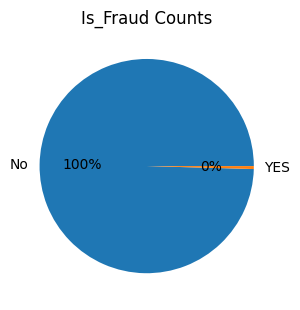

In [ ]:
df["is_fraud"].value_counts()
plt.figure(figsize=(6,10))
plt.subplot(1, 2, 1)

plt.pie(df["is_fraud"].value_counts() ,labels=["No", "YES"], autopct="%0.0f%%" )

plt.title("Is_Fraud Counts")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression()

In [ ]:
lr.fit(X_train,y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import classification_report

y_pred = lr.predict(X_test)
cr = classification_report(y_test, y_pred)
print(cr)


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     28614
         1.0       0.00      0.00      0.00       124

    accuracy                           1.00     28738
   macro avg       0.50      0.50      0.50     28738
weighted avg       0.99      1.00      0.99     28738



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[28614     0]
 [  124     0]]


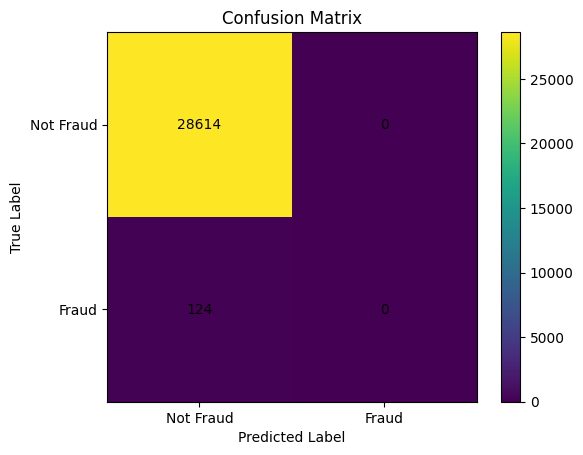

In [ ]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0,1], ["Not Fraud", "Fraud"])
plt.yticks([0,1], ["Not Fraud", "Fraud"])

# Add numbers inside boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()